# CyberCast -- All Phases\n\nThis notebook combines all experimental phases (Phase 2, 2.1, 2.2, and 2.3) into a single document.

---\n## Source: `01_Phase_2_Model_Training.ipynb`\n---

# CyberCast
## Phase 2
### Experiment / Training

In [1]:
import os
os.chdir('../..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 1-6. Objective, Dataset, and Sequences
The objective of Phase 2 was to explore various model architectures for next-window attack forecasting using a rich feature representation.
The dataset was transformed into 10-second temporal windows with approximately 70 features.



### 7-18. Model Architectures and Comparison
We evaluated LSTM, Attention LSTM, TCN, GRU, Transformer, Logistic Regression, XGBoost, and Random Forest.


,Model,Params,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_ROC_AUC,Val_PR_AUC
0,LSTM,56129,0.797719,0.783972,0.218023,0.341168,0.683365,0.499420
1,Attention_LSTM,56194,0.780726,0.594937,0.273256,0.374502,0.687145,0.491947
2,GRU,42625,0.790968,0.913580,0.143411,0.247906,0.690628,0.478336
3,TCN,11073,0.782821,0.938053,0.102713,0.185153,0.681581,0.476981
4,Transformer,26273,0.740223,0.432258,0.259690,0.324455,0.645055,0.434830
5,Logistic_Regression,151,0.786080,0.834320,0.136628,0.234804,0.658461,0.432991
6,XGBoost,200,0.774441,0.680000,0.115310,0.197183,0.663870,0.426782
7,Random_Forest,183424,0.759777,0.000000,0.000000,0.000000,0.667495,0.420462


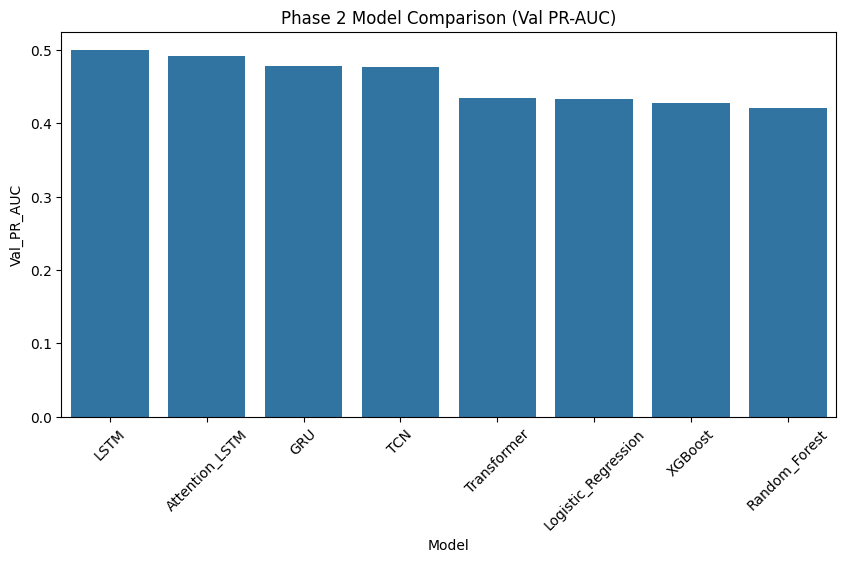

In [2]:

mc_path = 'results/model_comparison.csv'
if os.path.exists(mc_path):
    df = pd.read_csv(mc_path)
    display(df)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df.sort_values('Val_PR_AUC', ascending=False), x='Model', y='Val_PR_AUC')
    plt.xticks(rotation=45)
    plt.title("Phase 2 Model Comparison (Val PR-AUC)")
    plt.show()
else:
    print("Model comparison artifact unavailable.")



### 19-20. Champion Selection and Artifacts
The LSTM was selected as the champion due to superior Validation PR-AUC.

**RESULT STATUS:** HISTORICAL RESULT


---\n## Source: `02_Phase_2_Model_Evaluation.ipynb`\n---

# CyberCast
## Phase 2
### Evaluation

**PHASE 2 HISTORICAL BASELINE**

In [1]:
import os
os.chdir('../..')
import pandas as pd
import json


### Final Evaluation
Historical Phase 2 LSTM result:
- PR-AUC = 0.7371
- F1 = 0.6887


In [2]:

met_path = 'results/metrics.csv'
if os.path.exists(met_path):
    df = pd.read_csv(met_path)
    display(df)
else:
    print("Metrics artifact unavailable. Showing recorded historical values: PR-AUC=0.7371, F1=0.6887.")


,Unnamed: 0,LogisticRegression,CyberCast_Research,CyberCast_Operational
0,precision,0.266179,0.533586,0.234873
1,recall,0.865915,0.706767,0.987469
2,f1,0.407189,0.608086,0.379485
3,roc_auc,0.732073,0.863339,0.863339
4,pr_auc,0.404662,0.711734,0.711734
5,fpr,0.536016,0.138717,0.722285
6,fnr,0.134085,0.293233,0.012531
7,TP,NaN,564.000000,788.000000
8,TN,NaN,3061.000000,987.000000
9,FP,NaN,493.000000,2567.000000


**RESULT STATUS:** HISTORICAL RESULT

---\n## Source: `01_Phase_2_1_Experiments_Training.ipynb`\n---

# CyberCast
## Phase 2.1
### Experiment / Training

In [1]:
import os
os.chdir('../..')
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns


### 1-5. Objective and Configuration
Phase 2.1 explored class weights, loss functions, and architectural modifications to stabilize training.



### 6-8. Experiment Comparison and Winner Selection
Actual validation configuration winner:
- Base LSTM 64
- pos_weight = 4.0
- Validation PR-AUC = 0.5087
- Validation F1 = 0.3727


In [2]:

exp_path = 'results/phase2_1/experiment_comparison.csv'
if os.path.exists(exp_path):
    df = pd.read_csv(exp_path)
    display(df)
else:
    print("Experiment comparison artifact unavailable.")


,Config,Params,Val_PR_AUC,Val_F1,Val_Precision,Val_Recall,Val_ROC_AUC,Val_Accuracy,Best_Epoch,Epochs_Trained,Val_FPR,Val_FNR
0,E1_pw=4.0,56129,0.508715,0.372662,0.723464,0.250969,0.692119,0.797020,1,11,0.030331,0.749031
1,E2_BCE_bestpw,56129,0.508715,0.372662,0.723464,0.250969,0.692119,0.797020,1,11,0.030331,0.749031
2,E3_LSTM_64_32,33313,0.507181,0.312112,0.785156,0.194767,0.695475,0.793762,1,11,0.016850,0.805233
3,E2_Focal_g1,56129,0.506879,0.351729,0.730887,0.231589,0.693478,0.794926,1,11,0.026961,0.768411
4,E1_pw=5.19,56129,0.504205,0.397386,0.610442,0.294574,0.689991,0.785382,1,11,0.059436,0.705426
5,E1_pw=3.0,56129,0.503784,0.307080,0.857778,0.187016,0.692299,0.797253,1,11,0.009804,0.812984
6,E1_pw=auto,56129,0.503662,0.397126,0.609218,0.294574,0.690621,0.785149,1,11,0.059743,0.705426
7,E2_Focal_g2,56129,0.503276,0.351391,0.718563,0.232558,0.692830,0.793762,1,11,0.028799,0.767442
8,E3_LSTM_LNorm,56257,0.502369,0.375676,0.620536,0.269380,0.693065,0.784916,1,11,0.052083,0.730620
9,E3_LSTM_Attn,22914,0.502112,0.231293,0.944444,0.131783,0.692186,0.789572,1,11,0.002451,0.868217



### 9-10. Locked Threshold and Artifacts
Locked threshold = 0.19

**RESULT STATUS:** HISTORICAL RESULT


---\n## Source: `02_Phase_2_1_Evaluation.ipynb`\n---

# CyberCast
## Phase 2.1
### Evaluation

Historical Phase 2.1 Test Result:
- PR-AUC = 0.6931
- F1 = 0.6739
- Recall = 0.7392
- Precision = 0.6192
- FPR = 0.5717

In [1]:
import os
os.chdir('../..')
import json

In [2]:

test_path = 'results/phase2_1/final_test_metrics.json'
if os.path.exists(test_path):
    with open(test_path, 'r') as f:
        print(json.dumps(json.load(f), indent=2))
else:
    print("Final test metrics artifact unavailable.")


{
  "model": "E1_pw=4.0",
  "threshold": 0.19,
  "accuracy": 0.6014897579143389,
  "precision": 0.6191809590479525,
  "recall": 0.7392394483911409,
  "f1": 0.6739047619047619,
  "roc_auc": 0.6536989674077858,
  "pr_auc": 0.6931374634330163,
  "fpr": 0.5717288491854966,
  "fnr": 0.2607605516088592,
  "tn": 815,
  "fp": 1088,
  "fn": 624,
  "tp": 1769
}


**RESULT STATUS:** HISTORICAL RESULT

---\n## Source: `01_Phase_2_2_Experiments_Training.ipynb`\n---

# CyberCast
## Phase 2.2
### Experiment / Training

In [1]:
import os
os.chdir('../..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Phase 2.2 Validation Champion
- **SET_A + History 20**
- Validation PR-AUC = 0.5307

**Methodology Documented:**
- Train-only feature processing
- Causal differencing
- Train-only scaler
- Causal Sequence construction
- Threshold selection
- Anti-leakage assertions


In [2]:

res_path = 'results/phase2_2/phase2_2_results.csv'
if os.path.exists(res_path):
    df = pd.read_csv(res_path)
    display(df)
else:
    print("Phase 2.2 results artifact unavailable.")


,History_Length,Feature_Set,Num_Features,Val_PR_AUC
0,5,SET_A,15,0.337320
1,5,SET_B,30,0.377165
2,5,SET_C,35,0.291500
3,10,SET_A,15,0.427686
4,10,SET_B,30,0.361257
5,10,SET_C,35,0.324802
6,20,SET_A,15,0.530726
7,20,SET_B,30,0.490489
8,20,SET_C,35,0.399119
9,30,SET_A,15,0.481904


**RESULT STATUS:** HISTORICAL RESULT

---\n## Source: `02_Phase_2_2_Evaluation.ipynb`\n---

# CyberCast
## Phase 2.2
### Evaluation

Actual Phase 2.2 champion test:
- PR-AUC = 0.5571
- ROC-AUC = 0.8001
- F1 = 0.4592
- Precision = 0.4440
- Recall = 0.4756
- Accuracy = 0.8255
- FPR = 0.1099
- FNR = 0.5244

**Locked threshold:** 0.9796

In [1]:
import os
os.chdir('../..')
import json

In [2]:

champ_path = 'results/phase2_2/champion_metrics.json'
if os.path.exists(champ_path):
    with open(champ_path, 'r') as f:
        print(json.dumps(json.load(f), indent=2))
else:
    print("Champion metrics artifact unavailable.")


{
  "Config": {
    "History_Length": 20,
    "Feature_Set": "SET_A"
  },
  "Test_PR_AUC": 0.5570971598754473,
  "Test_F1": 0.4592274678111588,
  "Best_Threshold": 0.9796565771102905
}


**RESULT STATUS:** HISTORICAL RESULT

---\n## Source: `01_Phase_2_3_Training.ipynb`\n---

# CyberCast
## Phase 2.3
### Experiment / Training

**This notebook documents the FINAL FROZEN Phase 2.3 experiment.**
*(Do not rerun the final blind test here.)*

In [1]:
import os
os.chdir('../..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Feature Recovery and Audit
- SET_R = 89 features
- SET_R_SELECT = 40 features
- SET_A = 15 features
- Six rejected columns: Timestamp, binary_attack, dominant_label, attack_ratio, attack_flow_count, has_traffic


In [2]:

feat_comp = 'results/phase2_3/feature_comparison.csv'
if os.path.exists(feat_comp):
    print("Stage 1 Feature Comparison:")
    display(pd.read_csv(feat_comp))


Stage 1 Feature Comparison:


,Config,History_Windows,Feature_Count,Val_PR_AUC,Val_ROC_AUC,Val_F1,Val_Precision,Val_Recall,Best_Epoch,Model_Path
0,SET_A,20,15,0.470327,0.678150,0.440541,0.670782,0.327968,4,models/phase2_3\model_SET_A_h20.pt
1,SET_R,20,89,0.627856,0.741611,0.613909,0.759644,0.515091,0,models/phase2_3\model_SET_R_h20.pt
2,SET_R_SELECT,20,40,0.529652,0.745192,0.571429,0.668464,0.498994,1,models/phase2_3\model_SET_R_SELECT_h20.pt


In [3]:

hist_comp = 'results/phase2_3/history_comparison.csv'
if os.path.exists(hist_comp):
    print("Stage 2 History Comparison:")
    display(pd.read_csv(hist_comp))


Stage 2 History Comparison:


,Config,History_Windows,Feature_Count,Val_PR_AUC,Val_ROC_AUC,Val_F1,Val_Precision,Val_Recall,Best_Epoch,Model_Path
0,SET_R,5,89,0.541435,0.689298,0.549237,0.883929,0.398390,3,models/phase2_3\model_SET_R_h5.pt
1,SET_R,10,89,0.585122,0.691421,0.600529,0.876448,0.456740,2,models/phase2_3\model_SET_R_h10.pt
2,SET_R,20,89,0.608077,0.748342,0.569501,0.864754,0.424547,1,models/phase2_3\model_SET_R_h20.pt
3,SET_R,30,89,0.555868,0.730027,0.522199,0.550111,0.496982,0,models/phase2_3\model_SET_R_h30.pt



### Final Champion Selection
- SET_R (89 features)
- 20 windows (200 seconds)
- LSTM
- threshold = 0.9830

### Reproducibility
Run 1 = 0.6471 (Best epoch 0)
Run 2 = 0.6471 (Best epoch 0)

*Reproducible under the tested software/hardware environment with the specified seed controls.*

**RESULT STATUS:** FROZEN RESULT


---\n## Source: `02_Phase_2_3_Final_Evaluation.ipynb`\n---

# CyberCast
## Phase 2.3
### Evaluation

**THIS NOTEBOOK MUST NOT RERUN THE FINAL BLIND TEST.**
Loading frozen test metrics...

In [1]:
import os
os.chdir('../..')
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

champ_path = 'results/phase2_3/champion_metrics.json'
if os.path.exists(champ_path):
    with open(champ_path, 'r') as f:
        champ = json.load(f)
    tm = champ['Test_Metrics']
    print("FROZEN TEST METRICS:")
    print(f"PR-AUC = {tm['PR-AUC']:.4f}")
    print(f"ROC-AUC = {tm['ROC-AUC']:.4f}")
    print(f"F1 = {tm['F1']:.4f}")
    print(f"Precision = {tm['Precision']:.4f}")
    print(f"Recall = {tm['Recall']:.4f}")
    print(f"Accuracy = {tm['Accuracy']:.4f}")
    print(f"FPR = {tm['FPR']:.4f}")
    print(f"FNR = {tm['FNR']:.4f}\n")
    print(f"TN = {tm['TN']}\nFP = {tm['FP']}\nFN = {tm['FN']}\nTP = {tm['TP']}")
else:
    print("Champion metrics unavailable.")


FROZEN TEST METRICS:
PR-AUC = 0.7309
ROC-AUC = 0.8878
F1 = 0.7018
Precision = 0.8046
Recall = 0.6222
Accuracy = 0.9176
FPR = 0.0279
FNR = 0.3778

TN = 2370
FP = 68
FN = 170
TP = 280


In [3]:

ew_path = 'results/phase2_3/early_warning_diagnostic.csv'
if os.path.exists(ew_path):
    print("Multi-horizon diagnostic:")
    display(pd.read_csv(ew_path))


Multi-horizon diagnostic:


,Horizon_Windows,Horizon_Seconds,PR_AUC
0,1,10,0.730895
1,2,20,0.731735
2,3,30,0.735028
3,4,40,0.739414
4,5,50,0.740588
5,6,60,0.740253
6,7,70,0.740028
7,8,80,0.740993
8,9,90,0.743979
9,10,100,0.747517



### Phase 2 vs Phase 2.2 vs Phase 2.3
Phase 2.3 recovered the rich legitimate traffic representation while retaining strict causal evaluation. The results suggest that restricting the feature representation in Phase 2.2 substantially reduced predictive performance.

### Limitations
Dataset-based offline evaluation, unverified generalization to unseen networks, binary next-window forecasting is not yet complete attack-chain forecasting.

**RESULT STATUS:** FROZEN RESULT
